# Machine Learning training notebook
This notebook automates the following processes:
- Downloading the `puneet6060/intel-image-classification` Kaggle dataset to `./dataset`
- Runs the EDA and preprocessing
- Runs the traditional training pipeline
- Runs the modern training pipeline

In [1]:
import os
import sys

# 1. Setup environment specifically for Google Colab to fetch helper modules
if 'google.colab' in sys.modules:
    if not os.path.exists('ML_ASSIGNMENT'):
        !git clone https://github.com/PhatLavar/ML_ASSIGNMENT.git

    # Change directory so imports and file paths work exactly like local
    if os.path.exists('/content/ML_ASSIGNMENT'):
        %cd /content/ML_ASSIGNMENT
else:
    %cd ..

# 2. Install required libraries automatically
!pip install -r requirements.txt

print("Setup complete. Current working directory:", os.getcwd())

Cloning into 'ML_ASSIGNMENT'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 150 (delta 64), reused 140 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 6.42 MiB | 9.31 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/ML_ASSIGNMENT
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.6 MB/s eta 0:00:00
Setup complete. Current working directory: /content/ML_ASSIGNMENT


## Phase 1: EDA and Preprocessing
The data is downloaded from the public Kaggle dataset:
[Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

In [2]:
import os
from pathlib import Path
from modules.dataset_helper import zip_extraction

project_root = Path.cwd()

# Download
os.makedirs("dataset", exist_ok=True)
if not os.path.exists("./dataset/intel-image-classification.zip"):
    !gdown 1wWKbmBzE3voF8mWW5sdDLXrhBrwZ055m -O ./dataset/intel-image-classification.zip

# Extract Dataset
dataset_info = zip_extraction(project_root)

if dataset_info is None:
    print("Failed to fetch or extract dataset info.")
else:
    print("Dataset ready.")

Downloading...
From (original): https://drive.google.com/uc?id=1wWKbmBzE3voF8mWW5sdDLXrhBrwZ055m
From (redirected): https://drive.google.com/uc?id=1wWKbmBzE3voF8mWW5sdDLXrhBrwZ055m&confirm=t&uuid=d05da707-a323-476a-869d-b07c595d7149
To: /content/ML_ASSIGNMENT/dataset/intel-image-classification.zip
100% 363M/363M [00:06<00:00, 57.6MB/s]
[INFO] Extracting: /content/ML_ASSIGNMENT/dataset/intel-image-classification.zip
[INFO] Extraction completed into: /content/ML_ASSIGNMENT/dataset
[INFO] Flattening nested directory structures...
[INFO] Creating validation set (15% of train) at /content/ML_ASSIGNMENT/dataset/seg_val...
[INFO] Stratified validation set created.
Dataset ready.


In [3]:
from IPython.display import display
from modules.eda_helper import build_master_dataframe

df = build_master_dataframe(dataset_info)

display(df.head())
print("Master DataFrame built. Disk I/O is finished.")

Extracting metrics for 17034 images.


,filepath,split,class,filename,width,height,channels,dtype,file_bytes,phash,mean_r,mean_g,mean_b,std_r,std_g,std_b
0,/content/ML_ASSIGNMENT/dataset/seg_test/sea/20...,test,sea,20240.jpg,150,150,3,uint8,15136,96b84b99ad6a1635,103.010667,105.892756,102.658578,51.007836,51.921960,66.862500
1,/content/ML_ASSIGNMENT/dataset/seg_test/sea/21...,test,sea,21083.jpg,150,150,3,uint8,7605,91cc3b649b64c9b6,95.522667,127.710133,141.909200,78.630494,52.675744,51.175066
2,/content/ML_ASSIGNMENT/dataset/seg_test/sea/22...,test,sea,22675.jpg,150,150,3,uint8,10938,91ea6a699536169b,72.376489,61.232489,48.844844,60.998394,44.250293,26.786701
3,/content/ML_ASSIGNMENT/dataset/seg_test/sea/21...,test,sea,21973.jpg,150,150,3,uint8,9467,80a87729de2c57b9,124.671733,151.068089,168.692978,53.377581,36.431752,35.654227
4,/content/ML_ASSIGNMENT/dataset/seg_test/sea/23...,test,sea,23351.jpg,150,150,3,uint8,15465,edd20ebc7a774003,193.635333,177.320178,148.366933,71.217725,72.015844,71.476950


Master DataFrame built. Disk I/O is finished.


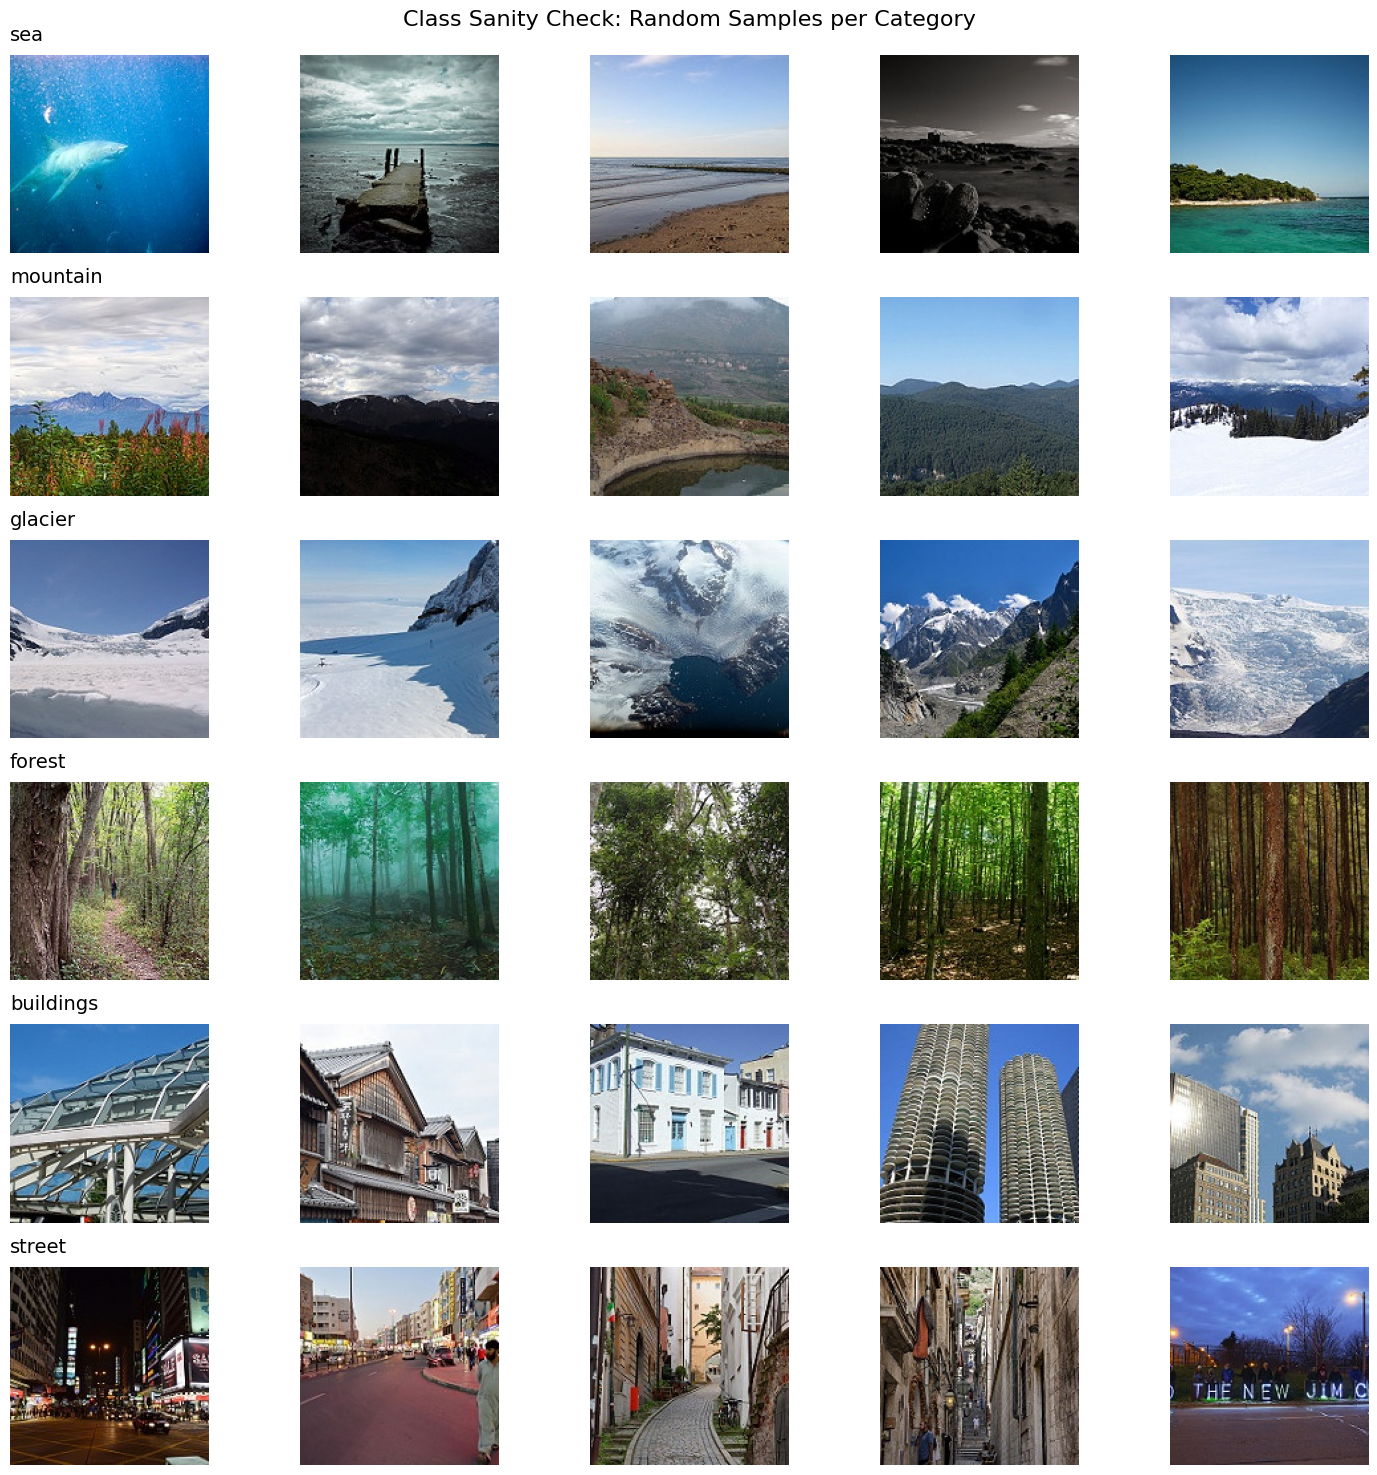

In [4]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Filter out corrupted files before sampling
valid_classes = df[df['class'] != 'Unknown']['class'].unique()

fig, axes = plt.subplots(len(valid_classes), 5, figsize=(15, 2.5 * len(valid_classes)))
fig.suptitle("Class Sanity Check: Random Samples per Category", fontsize=16)

for idx, cls in enumerate(valid_classes):
    # Grab 5 random filepaths for this specific class
    class_files = df[(df['class'] == cls) & (df['file_bytes'] > 0)]['filepath'].tolist()
    sample_files = random.sample(class_files, min(5, len(class_files)))

    for col_idx, img_path in enumerate(sample_files):
        ax = axes[idx, col_idx]
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(cls, fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

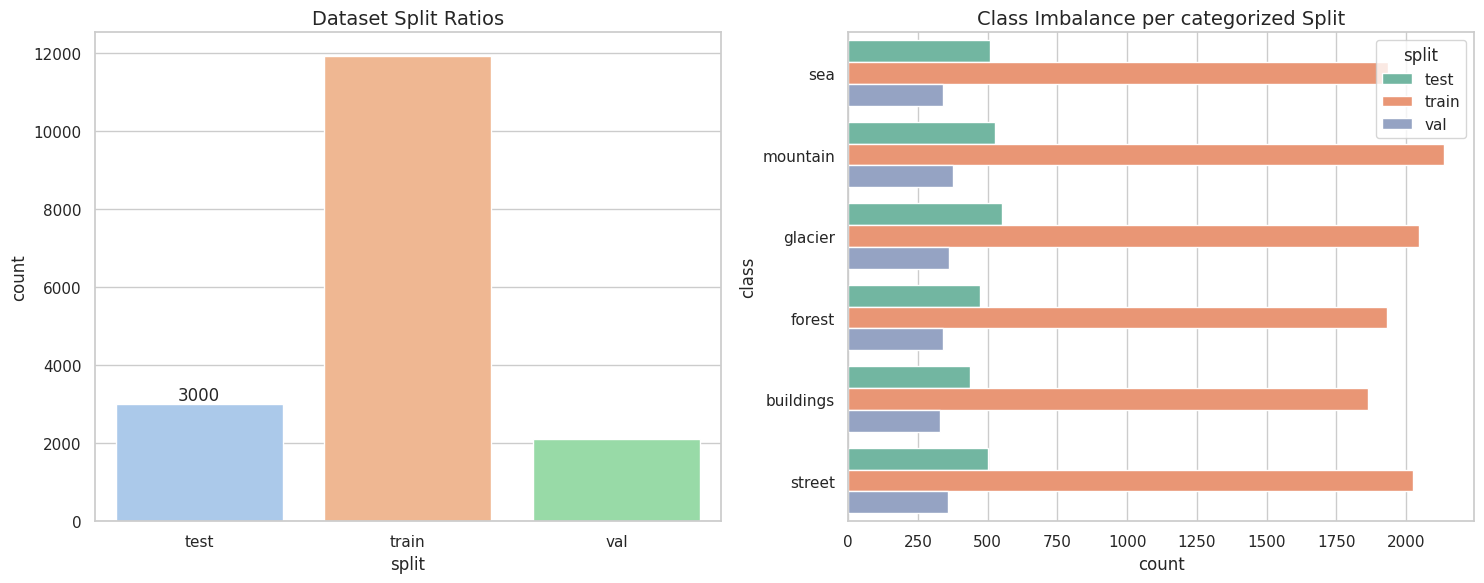

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall Split Distribution
sns.countplot(data=df, x='split', hue='split', ax=axes[0], palette="pastel", legend=False)
axes[0].set_title("Dataset Split Ratios", fontsize=14)
axes[0].bar_label(axes[0].containers[0])

# Class Breakdown inside Train/Val/Test
classified_df = df[df['class'] != 'Unknown']
sns.countplot(data=classified_df, y='class', hue='split', ax=axes[1], palette="Set2")
axes[1].set_title("Class Imbalance per categorized Split", fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from IPython.display import display

# 1. Empty or corrupted files
empty_files = df[df['file_bytes'] == 0]
unreadable = df[(df['width'].isna()) & (df['file_bytes'] > 0)]
print(f"Empty files (0 bytes): {len(empty_files)}")
print(f"Unreadable/Corrupted files: {len(unreadable)}")

# 2. File Extension Distribution
df['extension'] = df['filename'].str.lower().str.extract(r'(\.[^.]+)$', expand=False)
invalid_extensions = df[~df['extension'].isin({".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"})]

print(f"Non-image formats detected: {len(invalid_extensions)}")
display(df['extension'].value_counts().to_frame(name="Count"))

Empty files (0 bytes): 0
Unreadable/Corrupted files: 0
Non-image formats detected: 0


,Count
extension,
.jpg,17034


In [7]:
from modules.eda_helper import clean_dataset

clean_df = clean_dataset(df)

Original dataset size: 17034

Total Valid Images: 17034
Images at exactly 150x150: 16979 (99.68%)
Total Non-Square Images Detected: 55

Class Breakdown Summary:


,150x150 Count,Outlier Count
class,,
mountain,3018,19
glacier,2936,21
street,2882,1
sea,2780,4
forest,2736,9
buildings,2627,1


-> Removed 55 invalid, unknown, or non-square images.

Detected 51 redundant duplicate copies in the dataset.
Cross-Split Leakage (Images appearing in multiple splits):


split,test,train,val
phash,,,
820f4f43f7f6c181,1,1,0
84e4fa9e8cc2e1f2,0,2,0
85f67904e6799562,0,1,1
86c468be37111fce,0,2,0
86c6b918c6c7f531,0,2,0
86ceed6939861617,0,2,0
87a92e54972b4e95,0,1,1
87ba50679f15aac1,1,1,0
87e01fe25f01d44f,0,2,0


-> Removed 51 redundant images (Prioritized keeping test/val instances).

Final Cleaned Dataset Size: 16928



In [8]:
import os

# Delete files that were removed during cleaning so the full pipeline sees only clean data
kept = set(clean_df['filepath'])
removed = [p for p in df['filepath'] if p not in kept]
for p in removed:
    if os.path.exists(p):
        os.remove(p)
print(f"Deleted {len(removed)} files not in clean_df.")

Deleted 106 files not in clean_df.


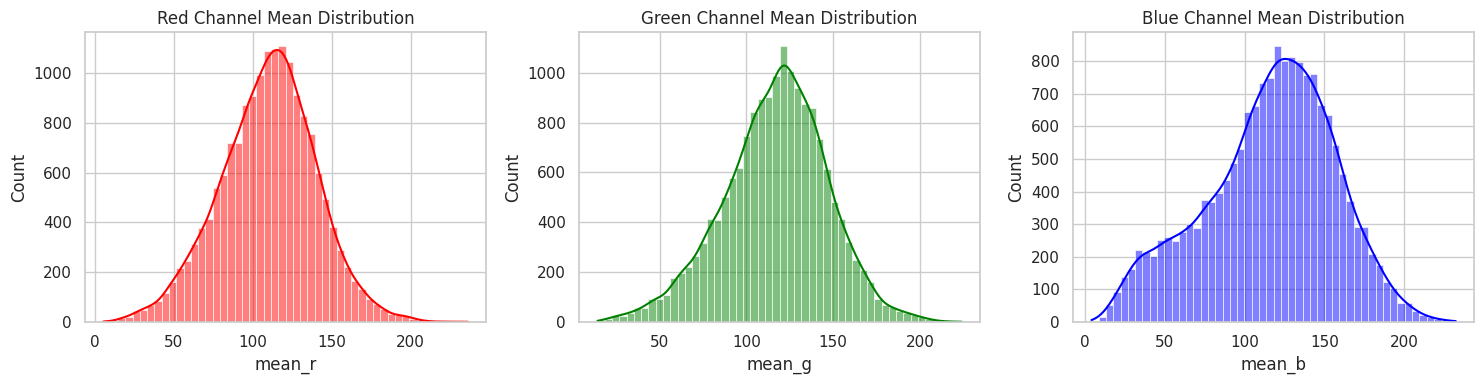


Recommended Dataset Normalization Metrics (0.0-1.0 scale)
Mean => R: 0.4308 | G: 0.4577 | B: 0.4542
Std  => R: 0.2358 | G: 0.2347 | B: 0.2431


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure we use the mathematically pure dataset from the previous step
final_stats = clean_df.dropna(subset=['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']).copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(final_stats['mean_r'], bins=50, ax=axes[0], color='red', kde=True)
axes[0].set_title("Red Channel Mean Distribution")

sns.histplot(final_stats['mean_g'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title("Green Channel Mean Distribution")

sns.histplot(final_stats['mean_b'], bins=50, ax=axes[2], color='blue', kde=True)
axes[2].set_title("Blue Channel Mean Distribution")

plt.tight_layout()
plt.show()

norm_mean_r = final_stats['mean_r'].mean() / 255.0
norm_mean_g = final_stats['mean_g'].mean() / 255.0
norm_mean_b = final_stats['mean_b'].mean() / 255.0

norm_std_r = final_stats['std_r'].mean() / 255.0
norm_std_g = final_stats['std_g'].mean() / 255.0
norm_std_b = final_stats['std_b'].mean() / 255.0

# Print global dataset means / stds useful for PyTorch/TensorFlow preprocessing configs
print("\nRecommended Dataset Normalization Metrics (0.0-1.0 scale)")
print(f"Mean => R: {norm_mean_r:.4f} | G: {norm_mean_g:.4f} | B: {norm_mean_b:.4f}")
print(f"Std  => R: {norm_std_r:.4f} | G: {norm_std_g:.4f} | B: {norm_std_b:.4f}")

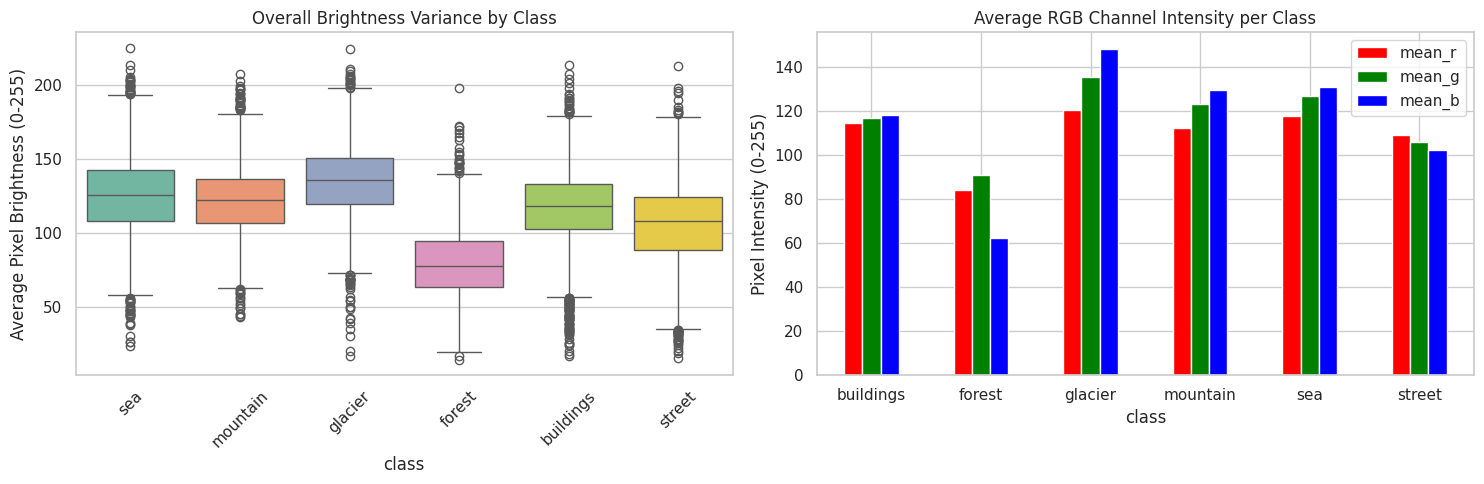

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate perceived overall brightness as a simple average of the RGB channels
final_stats['brightness'] = final_stats[['mean_r', 'mean_g', 'mean_b']].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Overall Brightness Variance
sns.boxplot(data=final_stats, x='class', y='brightness', hue='class', ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Overall Brightness Variance by Class")
axes[0].set_ylabel("Average Pixel Brightness (0-255)")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: RGB Means by Class
class_rgb_means = final_stats.groupby('class')[['mean_r', 'mean_g', 'mean_b']].mean()
class_rgb_means.plot(kind='bar', color=['red', 'green', 'blue'], ax=axes[1])
axes[1].set_title("Average RGB Channel Intensity per Class")
axes[1].set_ylabel("Pixel Intensity (0-255)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
from modules.dataset_helper import save_clean_dataset_and_metadata

save_clean_dataset_and_metadata(clean_df, project_root, norm_mean_r, norm_mean_g, norm_mean_b, norm_std_r, norm_std_g, norm_std_b)

Metadata (with split paths) successfully saved to /content/ML_ASSIGNMENT/dataset_metadata.json


## Phase 2: Traditional Pipeline

In [12]:
from pathlib import Path
from modules.dataset_helper import load_dataset_from_directories
from modules.traditional_helper import BasePreprocessor, HOGPreprocessor, SIFTPreprocessor, run_traditional_pipeline

# Ensure we use the clean dataset from Phase 1
project_root = Path.cwd()
clean_dl_df = clean_df.copy()
print(f"Loaded dataset for phase 2. Size: {len(clean_dl_df)}")

Loaded dataset for phase 2. Size: 16928


In [13]:
# Evaluate with vocab_size = 150 to reduce KMeans bottleneck
results_150_df, preds_150_dict, class_names_150 = run_traditional_pipeline(
    df=clean_dl_df,
    vocab_size=150,
    feature_configs=['hog', 'sift'],
    max_sift_samples=1500,
    pca_components=500,
    show_report=True
)

print("\n" + "="*50)
print("       FINAL MODEL COMPARISON (Vocab=150)")
print("="*50)
print(results_150_df.to_string(index=False))


 FEATURE EXTRACTION: HOG 
Extracting features for train split (11839 images)...
Extracting features for test split (2993 images)...
Applying PCA (n_components=500) to HOG...
-> Running HOG + SVM...
Detailed Report for HOG + SVM:
              precision    recall  f1-score   support

   buildings       0.75      0.70      0.72       437
      forest       0.83      0.95      0.88       473
     glacier       0.59      0.57      0.58       549
    mountain       0.54      0.55      0.55       523
         sea       0.65      0.63      0.64       510
      street       0.78      0.75      0.77       501

    accuracy                           0.69      2993
   macro avg       0.69      0.69      0.69      2993
weighted avg       0.68      0.69      0.68      2993

-> Running HOG + LR...
Detailed Report for HOG + LR:
              precision    recall  f1-score   support

   buildings       0.76      0.68      0.72       437
      forest       0.83      0.93      0.88       473
     glacie

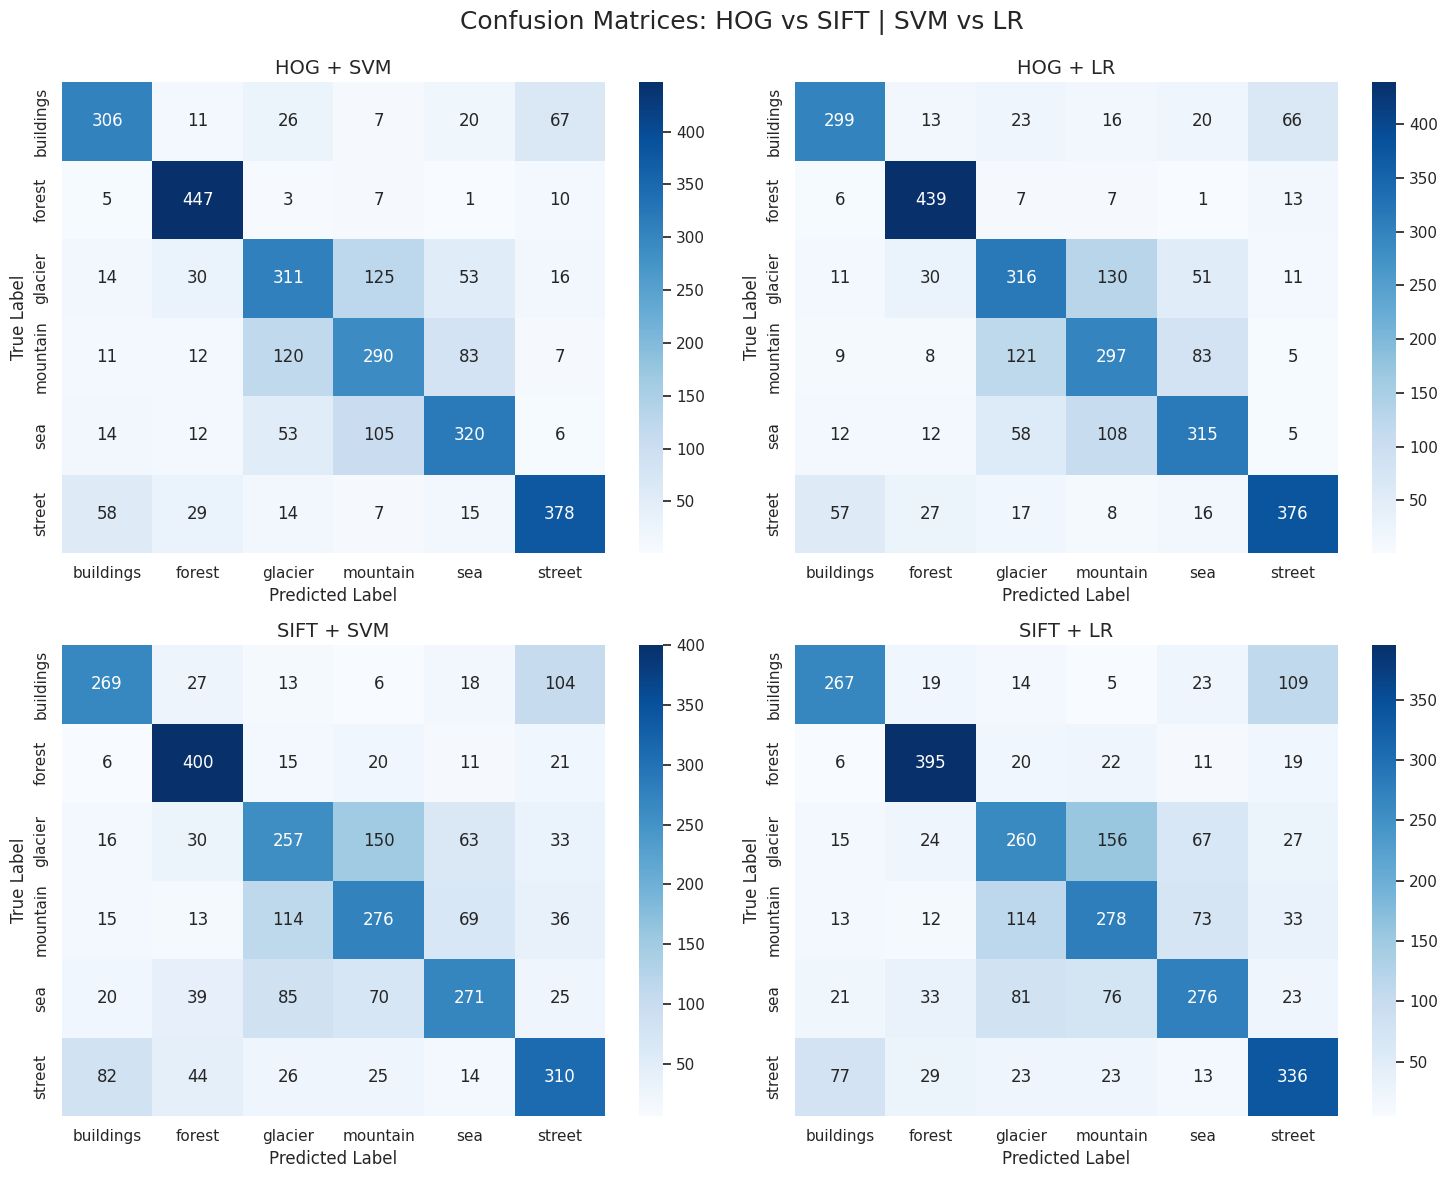

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

fig.suptitle("Confusion Matrices: HOG vs SIFT | SVM vs LR", fontsize=18)

for idx, (exp_name, (y_test_true, y_pred_model)) in enumerate(preds_150_dict.items()):
    if idx >= 4:
        break
    cm = confusion_matrix(y_test_true, y_pred_model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names_150, yticklabels=class_names_150) # Changed class names
    axes[idx].set_title(f"{exp_name}", fontsize=14)
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## Phase 3: Deep Learning Pipeline

In [15]:
from modules.deep_learning_helper import load_metadata
import torch

# 1. Load the metadata saved from Phase 1
metadata = load_metadata("dataset_metadata.json")

norm_mean = metadata["normalization"]["mean"]
norm_std = metadata["normalization"]["std"]
input_size = tuple(metadata["input_size"])
target_names = metadata["classes"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loaded Normalization Mean: {norm_mean}")
print(f"Loaded Normalization Std: {norm_std}")
print(f"Input Size: {input_size}")
print(f"Using device: {device}")

Loaded Normalization Mean: [0.43084844571498, 0.45771191525507493, 0.45422619788642193]
Loaded Normalization Std: [0.23576279901554525, 0.2346502674754036, 0.24307003911120406]
Input Size: (150, 150)
Using device: cuda


In [16]:
from modules.deep_learning_helper import get_transforms, get_dataloaders

# 2. Setup PyTorch Transforms and DataLoaders
train_transform, test_transform = get_transforms(metadata)
train_loader, test_loader = get_dataloaders(metadata, train_transform, test_transform,
                                            batch_size=32, valid_files=set(clean_dl_df['filepath']))

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

Training batches: 370
Testing batches: 94


In [17]:
from modules.deep_learning_helper import get_feature_extractor

# 3. Initialize the pre-trained ResNet18 model as a feature extractor
model = get_feature_extractor(device)
print("ResNet18 initialized as a feature extractor.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


ResNet18 initialized as a feature extractor.


In [18]:
from modules.deep_learning_helper import batch_extract_features
import numpy as np
import os

# Define and create the features directory
features_dir = "./features"
os.makedirs(features_dir, exist_ok=True)

# 4. Extract capabilities: Pass datasets through ResNet18 to yield deep features
print("Extracting features for train split...")
X_train_dl, y_train_dl = batch_extract_features(train_loader, model, device)

print("Extracting features for test split...")
X_test_dl, y_test_dl = batch_extract_features(test_loader, model, device)

# Save to .npy format inside the new features folder
np.save(os.path.join(features_dir, 'X_train_resnet18.npy'), X_train_dl)
np.save(os.path.join(features_dir, 'y_train_resnet18.npy'), y_train_dl)
np.save(os.path.join(features_dir, 'X_test_resnet18.npy'), X_test_dl)
np.save(os.path.join(features_dir, 'y_test_resnet18.npy'), y_test_dl)

print(f"-> Extracted features saved to the '{features_dir}/' directory successfully.")

Extracting features for train split...
Extracting features for test split...
-> Extracted features saved to the './features/' directory successfully.


In [19]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 5. Train Classical Machine Learning classifiers on top of the DL feature embeddings
print("\n-> Running ResNet18 Features + SVM...")
svm_clf = LinearSVC(max_iter=2000, dual=False)
svm_clf.fit(X_train_dl, y_train_dl)
y_pred_svm = svm_clf.predict(X_test_dl)

print("Detailed Report for ResNet18 + SVM:")
print(classification_report(y_test_dl, y_pred_svm, target_names=target_names, digits=4))
print(f"Accuracy: {accuracy_score(y_test_dl, y_pred_svm):.4f}")

print("\n-> Running ResNet18 Features + LR...")
lr_clf = LogisticRegression(max_iter=2000)
lr_clf.fit(X_train_dl, y_train_dl)
y_pred_lr = lr_clf.predict(X_test_dl)

print("Detailed Report for ResNet18 + LR:")
print(classification_report(y_test_dl, y_pred_lr, target_names=target_names, digits=4))
print(f"Accuracy: {accuracy_score(y_test_dl, y_pred_lr):.4f}")


-> Running ResNet18 Features + SVM...
Detailed Report for ResNet18 + SVM:
              precision    recall  f1-score   support

   buildings     0.8378    0.9222    0.8780       437
      forest     0.9828    0.9683    0.9755       473
     glacier     0.8346    0.7996    0.8167       549
    mountain     0.8373    0.8069    0.8218       523
         sea     0.8976    0.9451    0.9207       510
      street     0.9061    0.8663    0.8857       501

    accuracy                         0.8814      2993
   macro avg     0.8827    0.8847    0.8831      2993
weighted avg     0.8817    0.8814    0.8809      2993

Accuracy: 0.8814

-> Running ResNet18 Features + LR...
Detailed Report for ResNet18 + LR:
              precision    recall  f1-score   support

   buildings     0.8471    0.9130    0.8789       437
      forest     0.9786    0.9683    0.9734       473
     glacier     0.7978    0.7760    0.7867       549
    mountain     0.8137    0.7935    0.8035       523
         sea     0.88

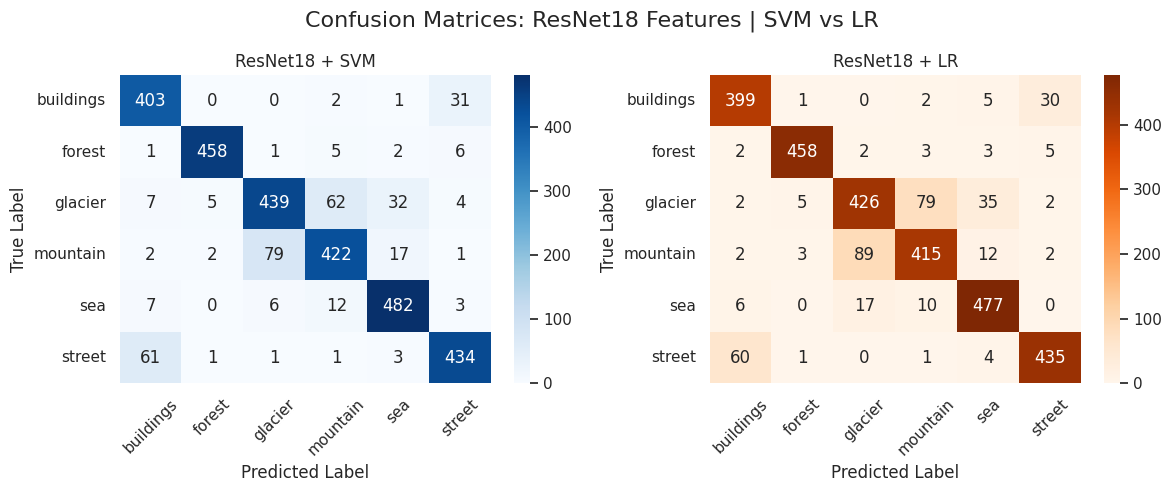

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 6. Visualize the evaluations using Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices: ResNet18 Features | SVM vs LR", fontsize=16)

# SVM Heatmap
cm_svm = confusion_matrix(y_test_dl, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title("ResNet18 + SVM")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
# Rotate both axes labels
axes[0].set_xticklabels(target_names, rotation=45)
axes[0].set_yticklabels(target_names, rotation=0)

# LR Heatmap
cm_lr = confusion_matrix(y_test_dl, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title("ResNet18 + LR")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
# Rotate both axes labels
axes[1].set_xticklabels(target_names, rotation=45)
axes[1].set_yticklabels(target_names, rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()